# Exploratory data analysis

Before implementing any models, any embedding... any code that manipulates the data, I want to discover the raw dataset and try answer some questions. I used this notebook to analyse properly the dataset. When I have any question relative to the dataset, I always go back to this notebook in order to find my answers, even at the last steps of coding the final recommender system.

## Importing libraries

In [85]:
import pandas as pd
import seaborn as sns
import dataset_loader
import matplotlib.pyplot as plt
import numpy as np

rootpath = '../kuairec/'

## Load dataset

For loading the dataset throughout the entire project, I use my custom Python script `dataset_loader`. It contains multiple functions to load and preprocess the dataset so that I can reuse code wisely at every stages of the project. I essentially built those functions in parallel of this current notebook as I have found new issues with the data by manipulating the dataset at the first time.

See `dataset_loader.py` for more details on the functions used.

In [86]:
big, small, social, items, item_daily, users, captions = dataset_loader.load_dataset()

Loading big_interactions...
Loading small_interactions...
Loading social...
Loading item...
Loading item_daily...
Loading user...
Loading caption...


Here are the description of each dataframes above:
- `big`: big matrix containing the interactions between users and videos (i.e. items). I use this matrix as my training/validation sets.
- `small`: same as the big one except that I use this matrix as my test set.
- `social`: interactions between users (friendship relations)
- `items`: video tags
- `item_daily`: daily statistics about each video
- `captions`: video captions, title in simplified chinese

## Raw visualization

What I call raw visualization is to understand the shapes of the data that I manipulate and start by getting familiar with the columns and values that I manipulate. I think it is very important to know the size and the amount of the data that I manipulate to visualize more and understand better what I will code later.

In [87]:
print(f'Big matrix shape: {big.shape}')
print(f'Small matrix shape: {small.shape}')
print(f'Social network shape: {social.shape}')
print(f'Item features shape: {items.shape}')
print(f'User features shape: {users.shape}')
print(f'Item daily features shape: {item_daily.shape}')

Big matrix shape: (11564987, 8)
Small matrix shape: (4494578, 8)
Social network shape: (472, 2)
Item features shape: (10728, 2)
User features shape: (7176, 31)
Item daily features shape: (343341, 58)


In [88]:
big.head()

,user_id,video_id,play_duration,video_duration,time,date,timestamp,watch_ratio
0,0,3649,13838,10867,2020-07-05 00:08:23.438,20200705,1.593879e+09,1.273397
1,0,9598,13665,10984,2020-07-05 00:13:41.297,20200705,1.593879e+09,1.244082
2,0,5262,851,7908,2020-07-05 00:16:06.687,20200705,1.593879e+09,0.107613
3,0,1963,862,9590,2020-07-05 00:20:26.792,20200705,1.593880e+09,0.089885
4,0,8234,858,11000,2020-07-05 00:43:05.128,20200705,1.593881e+09,0.078000


In [89]:
big.dtypes

user_id             int64
video_id            int64
play_duration       int64
video_duration      int64
time               object
date                int64
timestamp         float64
watch_ratio       float64
dtype: object

In [90]:
small.head()

,user_id,video_id,play_duration,video_duration,time,date,timestamp,watch_ratio
0,14,148,4381,6067,2020-07-05 05:27:48.378,20200705.0,1.593898e+09,0.722103
1,14,183,11635,6100,2020-07-05 05:28:00.057,20200705.0,1.593898e+09,1.907377
2,14,3649,22422,10867,2020-07-05 05:29:09.479,20200705.0,1.593898e+09,2.063311
3,14,5262,4479,7908,2020-07-05 05:30:43.285,20200705.0,1.593898e+09,0.566388
4,14,8234,4602,11000,2020-07-05 05:35:43.459,20200705.0,1.593899e+09,0.418364


In [91]:
small.dtypes

user_id             int64
video_id            int64
play_duration       int64
video_duration      int64
time               object
date              float64
timestamp         float64
watch_ratio       float64
dtype: object

In [92]:
social.head()

,user_id,friend_list
0,3371,[2975]
1,24,[2665]
2,4402,[38]
3,4295,[4694]
4,7087,[7117]


In [93]:
social.dtypes

user_id         int64
friend_list    object
dtype: object

In [94]:
items.head()

,video_id,feat
0,0,[8]
1,1,"[27, 9]"
2,2,[9]
3,3,[26]
4,4,[5]


In [95]:
items.dtypes

video_id     int64
feat        object
dtype: object

In [96]:
users.head()

,user_id,user_active_degree,is_lowactive_period,is_live_streamer,is_video_author,follow_user_num,follow_user_num_range,fans_user_num,fans_user_num_range,friend_user_num,...,onehot_feat8,onehot_feat9,onehot_feat10,onehot_feat11,onehot_feat12,onehot_feat13,onehot_feat14,onehot_feat15,onehot_feat16,onehot_feat17
0,0,high_active,0,0,0,5,"(0,10]",0,0,0,...,184,6,3,0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,full_active,0,0,0,386,"(250,500]",4,"[1,10)",2,...,186,6,2,0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,full_active,0,0,0,27,"(10,50]",0,0,0,...,51,2,3,0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,full_active,0,0,0,16,"(10,50]",0,0,0,...,251,3,2,0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,full_active,0,0,0,122,"(100,150]",4,"[1,10)",0,...,99,4,2,0,0.0,0.0,0.0,0.0,0.0,0.0


In [97]:
users.dtypes

user_id                    int64
user_active_degree        object
is_lowactive_period        int64
is_live_streamer           int64
is_video_author            int64
follow_user_num            int64
follow_user_num_range     object
fans_user_num              int64
fans_user_num_range       object
friend_user_num            int64
friend_user_num_range     object
register_days              int64
register_days_range       object
onehot_feat0               int64
onehot_feat1               int64
onehot_feat2               int64
onehot_feat3               int64
onehot_feat4             float64
onehot_feat5               int64
onehot_feat6               int64
onehot_feat7               int64
onehot_feat8               int64
onehot_feat9               int64
onehot_feat10              int64
onehot_feat11              int64
onehot_feat12            float64
onehot_feat13            float64
onehot_feat14            float64
onehot_feat15            float64
onehot_feat16            float64
onehot_fea

In [98]:
item_daily.head()

,video_id,date,author_id,video_type,upload_dt,upload_type,visible_status,video_duration,video_width,video_height,...,download_cnt,download_user_num,report_cnt,report_user_num,reduce_similar_cnt,reduce_similar_user_num,collect_cnt,collect_user_num,cancel_collect_cnt,cancel_collect_user_num
0,0,20200705,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,8,8,0,0,3,3,NaN,NaN,NaN,NaN
1,0,20200706,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,2,2,0,0,5,5,NaN,NaN,NaN,NaN
2,0,20200707,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,2,2,0,0,0,0,NaN,NaN,NaN,NaN
3,0,20200708,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,3,3,0,0,3,3,NaN,NaN,NaN,NaN
4,0,20200709,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,2,2,2,1,1,1,NaN,NaN,NaN,NaN


In [99]:
item_daily.dtypes

video_id                      int64
date                          int64
author_id                     int64
video_type                   object
upload_dt                    object
upload_type                  object
visible_status               object
video_duration              float64
video_width                   int64
video_height                  int64
music_id                      int64
video_tag_id                  int64
video_tag_name               object
show_cnt                      int64
show_user_num                 int64
play_cnt                      int64
play_user_num                 int64
play_duration                 int64
complete_play_cnt             int64
complete_play_user_num        int64
valid_play_cnt                int64
valid_play_user_num           int64
long_time_play_cnt            int64
long_time_play_user_num       int64
short_time_play_cnt           int64
short_time_play_user_num      int64
play_progress               float64
comment_stay_duration       

To analyse further, let's rename the `small` matrix by `interactions` to avoid any embiguities.

In [100]:
interactions = small

In [101]:
interactions.head()

,user_id,video_id,play_duration,video_duration,time,date,timestamp,watch_ratio
0,14,148,4381,6067,2020-07-05 05:27:48.378,20200705.0,1.593898e+09,0.722103
1,14,183,11635,6100,2020-07-05 05:28:00.057,20200705.0,1.593898e+09,1.907377
2,14,3649,22422,10867,2020-07-05 05:29:09.479,20200705.0,1.593898e+09,2.063311
3,14,5262,4479,7908,2020-07-05 05:30:43.285,20200705.0,1.593898e+09,0.566388
4,14,8234,4602,11000,2020-07-05 05:35:43.459,20200705.0,1.593899e+09,0.418364


In [102]:
interactions.dtypes

user_id             int64
video_id            int64
play_duration       int64
video_duration      int64
time               object
date              float64
timestamp         float64
watch_ratio       float64
dtype: object

In [103]:
# Fixes some issues with the data type of "timestamp"

interactions['time'] = pd.to_datetime(interactions['time'])
interactions["timestamp"] = pd.to_datetime(
    interactions["timestamp"].fillna(0), unit="s"
)

In [104]:
interactions.dtypes

user_id                    int64
video_id                   int64
play_duration              int64
video_duration             int64
time              datetime64[ns]
date                     float64
timestamp         datetime64[ns]
watch_ratio              float64
dtype: object

In [ ]:
# Checking if there is any NaN values in columns
interactions.isna().any(axis=0)

user_id           False
video_id          False
play_duration     False
video_duration    False
time              False
date              False
timestamp         False
watch_ratio       False
dtype: bool

In [106]:
# Dropping some rows and checking the impact on the size of the dataframe

print(f'Initial shape {interactions.shape}')
interactions = interactions.dropna()
print(f'After dropna {interactions.shape}')

Initial shape (4494578, 8)
After dropna (4494578, 8)


In [107]:
len(users), len(items)

(7176, 10728)

In [108]:
# Finding the start and end time when data was recorded

interactions['time'].min(), interactions['time'].max()

(Timestamp('2020-07-04 02:23:26.060000'),
 Timestamp('2020-09-05 23:57:23.683000'))

As we can see, the data has been captured from April, 04, 2020 to September, 05, 2020. It confirms the dates I read in the paper that comes with the dataset.

## Plotting data

I have now some intuition about the data, its shapes and its types. Now the idea is to plot the data in order to visualize distribution of features and emphesize the interaction between items and users.

In [109]:
# Adding columns to plot the data

interactions['hour'] = interactions['timestamp'].dt.hour
interactions['day'] = interactions['timestamp'].dt.day
interactions['day_of_week'] = interactions['timestamp'].dt.day_of_week
interactions['month'] = interactions['timestamp'].dt.month

In [110]:
interactions['user_id'].value_counts().shape

(1411,)

In [111]:
interactions['video_id'].value_counts().shape

(3327,)

In [112]:
interactions.head()

,user_id,video_id,play_duration,video_duration,time,date,timestamp,watch_ratio,hour,day,day_of_week,month
0,14,148,4381,6067,2020-07-05 05:27:48.378,20200705.0,2020-07-04 21:27:48.378000021,0.722103,21,4,5,7
1,14,183,11635,6100,2020-07-05 05:28:00.057,20200705.0,2020-07-04 21:28:00.056999922,1.907377,21,4,5,7
2,14,3649,22422,10867,2020-07-05 05:29:09.479,20200705.0,2020-07-04 21:29:09.479000092,2.063311,21,4,5,7
3,14,5262,4479,7908,2020-07-05 05:30:43.285,20200705.0,2020-07-04 21:30:43.285000086,0.566388,21,4,5,7
4,14,8234,4602,11000,2020-07-05 05:35:43.459,20200705.0,2020-07-04 21:35:43.459000111,0.418364,21,4,5,7


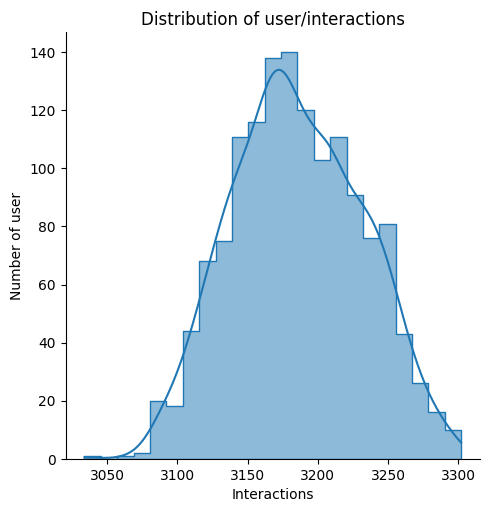

In [113]:
# Using seaborn
sns.displot(interactions['user_id'].value_counts(), element='step', kde=True).set(title='Distribution of user/interactions', xlabel='Interactions', ylabel='Number of user')

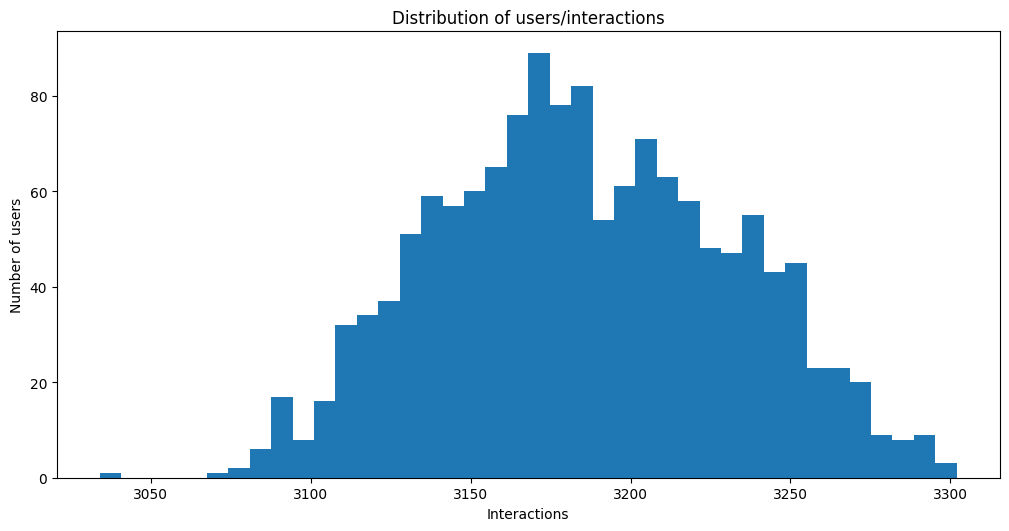

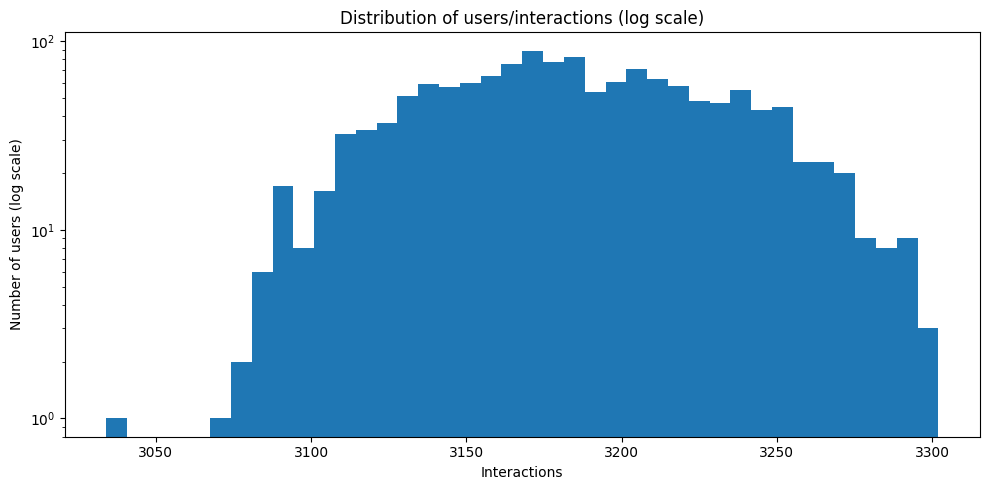

In [114]:
# Using pyplot 

plt.figure(figsize=(10,5))
plt.hist(interactions['user_id'].value_counts(), bins=40)
plt.tight_layout()
plt.title('Distribution of users/interactions')
plt.xlabel('Interactions')
plt.ylabel('Number of users')
plt.show()

plt.figure(figsize=(10,5))
plt.hist(interactions['user_id'].value_counts(), bins=40)
plt.yscale('log')
plt.title('Distribution of users/interactions (log scale)')
plt.xlabel('Interactions')
plt.ylabel('Number of users (log scale)')
plt.tight_layout()
plt.show()

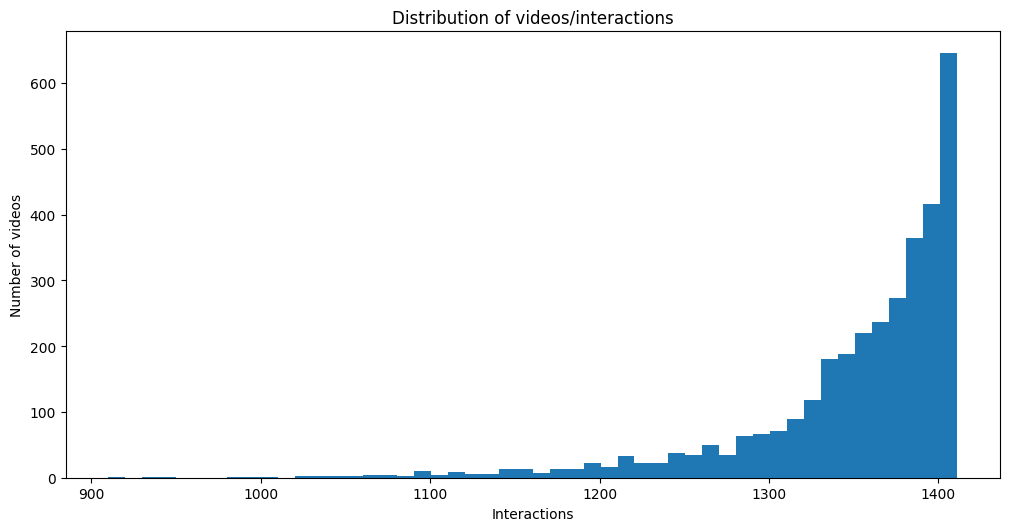

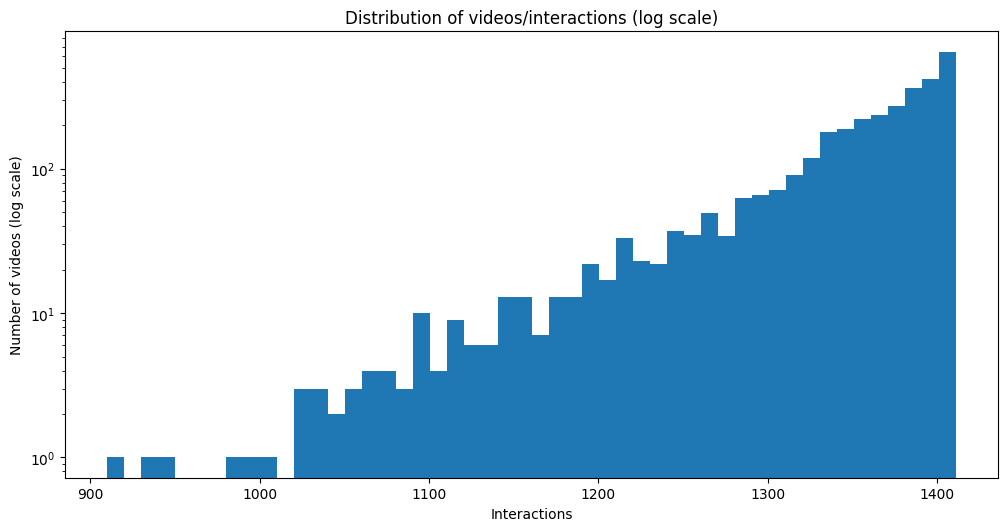

In [115]:
plt.figure(figsize=(10,5))
plt.hist(interactions['video_id'].value_counts(), bins=50)
plt.tight_layout()
plt.title('Distribution of videos/interactions')
plt.xlabel('Interactions')
plt.ylabel('Number of videos')
plt.show()

plt.figure(figsize=(10,5))
plt.hist(interactions['video_id'].value_counts(), bins=50)
plt.tight_layout()
plt.title('Distribution of videos/interactions (log scale)')
plt.xlabel('Interactions')
plt.ylabel('Number of videos (log scale)')
plt.yscale('log')
plt.show()



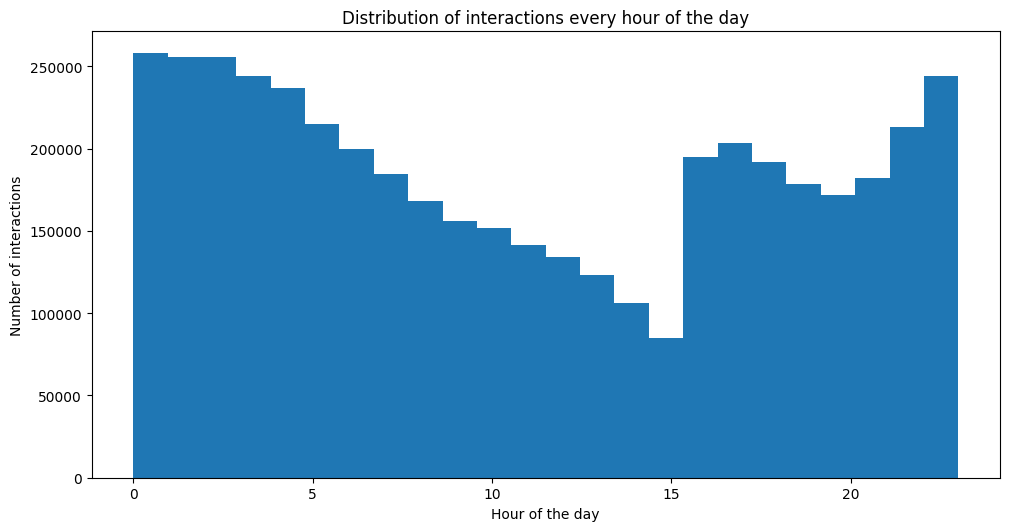

In [116]:
plt.figure(figsize=(10,5))
plt.hist(interactions['hour'], bins=24)
plt.tight_layout()
plt.title('Distribution of interactions every hour of the day')
plt.xlabel('Hour of the day')
plt.ylabel('Number of interactions')
plt.show()

In [117]:
interactions.head()

,user_id,video_id,play_duration,video_duration,time,date,timestamp,watch_ratio,hour,day,day_of_week,month
0,14,148,4381,6067,2020-07-05 05:27:48.378,20200705.0,2020-07-04 21:27:48.378000021,0.722103,21,4,5,7
1,14,183,11635,6100,2020-07-05 05:28:00.057,20200705.0,2020-07-04 21:28:00.056999922,1.907377,21,4,5,7
2,14,3649,22422,10867,2020-07-05 05:29:09.479,20200705.0,2020-07-04 21:29:09.479000092,2.063311,21,4,5,7
3,14,5262,4479,7908,2020-07-05 05:30:43.285,20200705.0,2020-07-04 21:30:43.285000086,0.566388,21,4,5,7
4,14,8234,4602,11000,2020-07-05 05:35:43.459,20200705.0,2020-07-04 21:35:43.459000111,0.418364,21,4,5,7


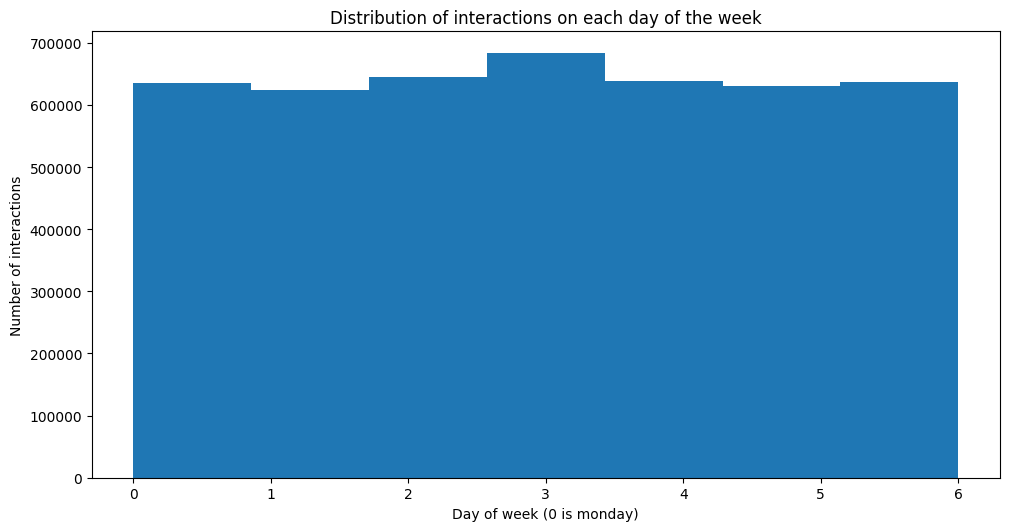

In [118]:
plt.figure(figsize=(10,5))
plt.hist(interactions['day_of_week'], bins=7)
plt.tight_layout()
plt.title('Distribution of interactions on each day of the week')
plt.xlabel('Day of week (0 is monday)')
plt.ylabel('Number of interactions')
plt.show()

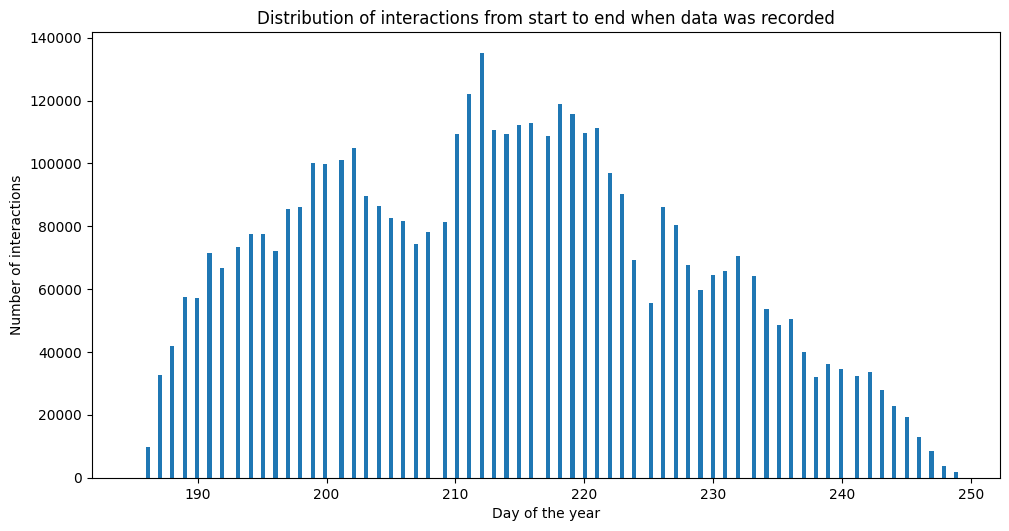

In [119]:
plt.figure(figsize=(10,5))
plt.hist(interactions['timestamp'].dt.day_of_year, bins=200)
plt.tight_layout()
plt.title('Distribution of interactions from start to end when data was recorded')
plt.xlabel('Day of the year')
plt.ylabel('Number of interactions')
plt.show()

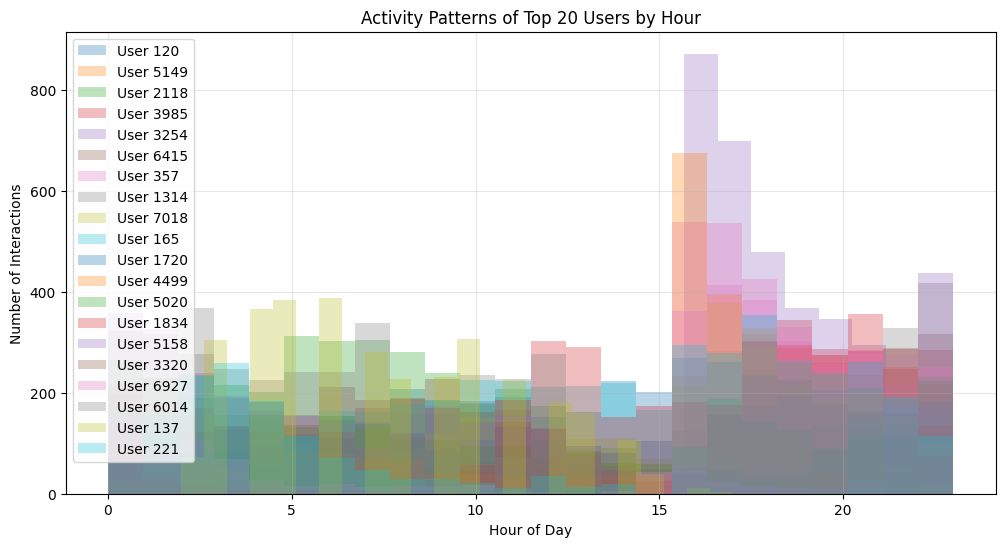

In [120]:
top_users = interactions['user_id'].value_counts().head(20).index
plt.figure(figsize=(12, 6))
for user in top_users:
    user_data = interactions[interactions["user_id"] == user]
    plt.hist(user_data["hour"], bins=24, alpha=0.3, label=f"User {user}")
plt.title("Activity Patterns of Top 20 Users by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Interactions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

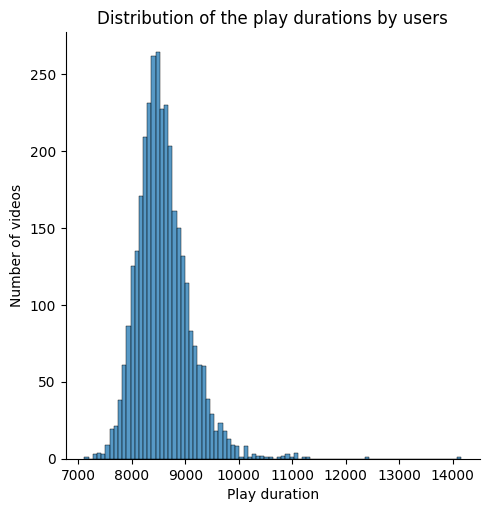

In [121]:
sns.displot(interactions.groupby('video_id')['play_duration'].mean()).set(title='Distribution of the play durations by users', xlabel='Play duration', ylabel='Number of videos')


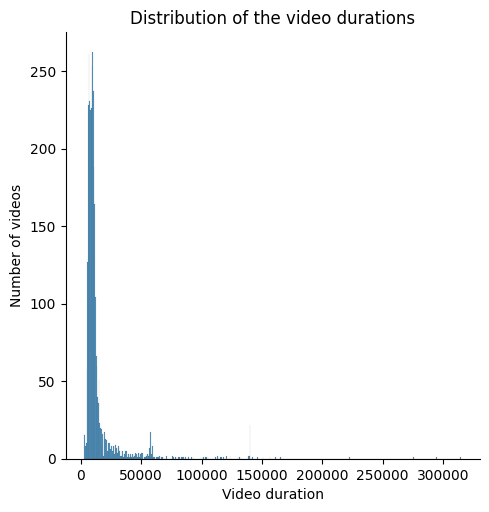

In [122]:
sns.displot(interactions.groupby('video_id')['video_duration'].mean()).set(title='Distribution of the video durations', xlabel='Video duration', ylabel='Number of videos')

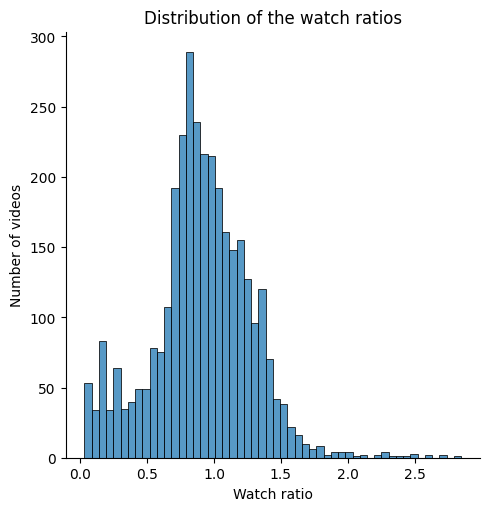

In [123]:
sns.displot(interactions.groupby('video_id')['watch_ratio'].mean()).set(title='Distribution of the watch ratios', xlabel='Watch ratio', ylabel='Number of videos')

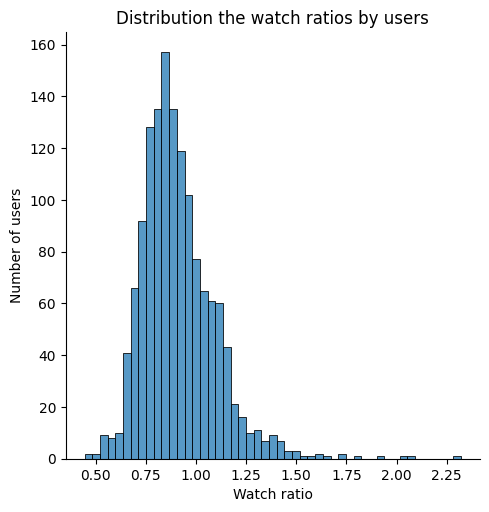

In [124]:
sns.displot(interactions.groupby('user_id')['watch_ratio'].mean()).set(title='Distribution the watch ratios by users', xlabel='Watch ratio', ylabel='Number of users')

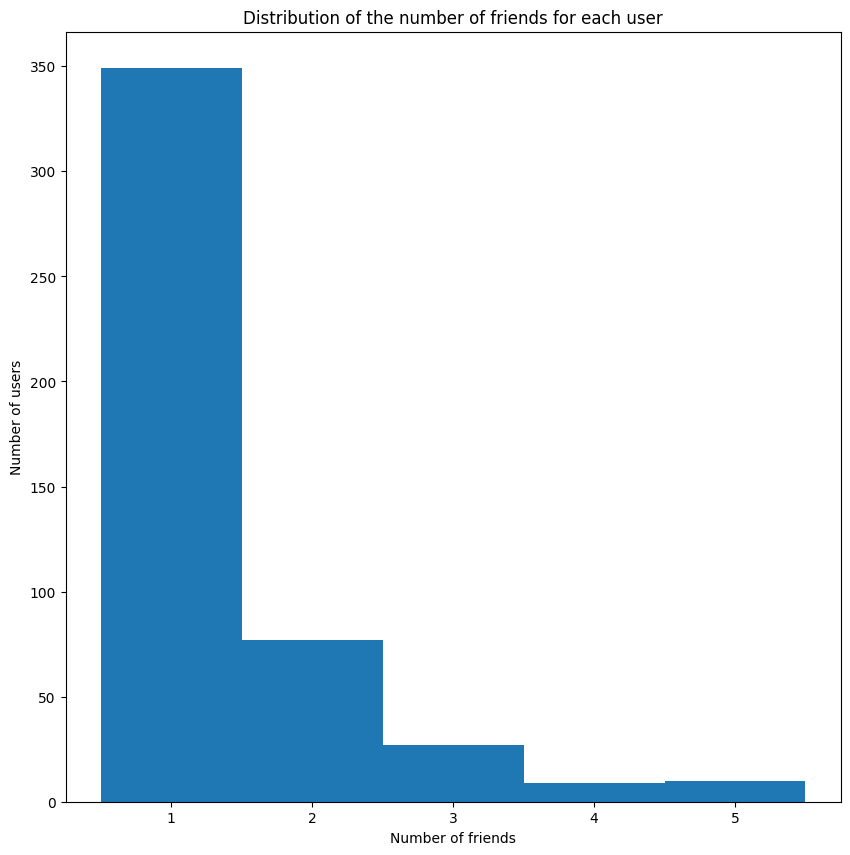

In [125]:
plt.figure(figsize=(10, 10))
friends = social['friend_list'].apply(len)
plt.hist(friends, bins=np.arange(friends.min(), friends.max() + 2) - 0.5)
plt.xticks(np.arange(friends.min(), friends.max() + 1))
plt.xlabel('Number of friends')
plt.ylabel('Number of users')
plt.title('Distribution of the number of friends for each user')
plt.show()

In [126]:
items = items[items['video_id'].isin(interactions['video_id'])]
users = users[users['user_id'].isin(interactions['user_id'])]

In [127]:
items.shape, users.shape

((3327, 2), (1411, 31))

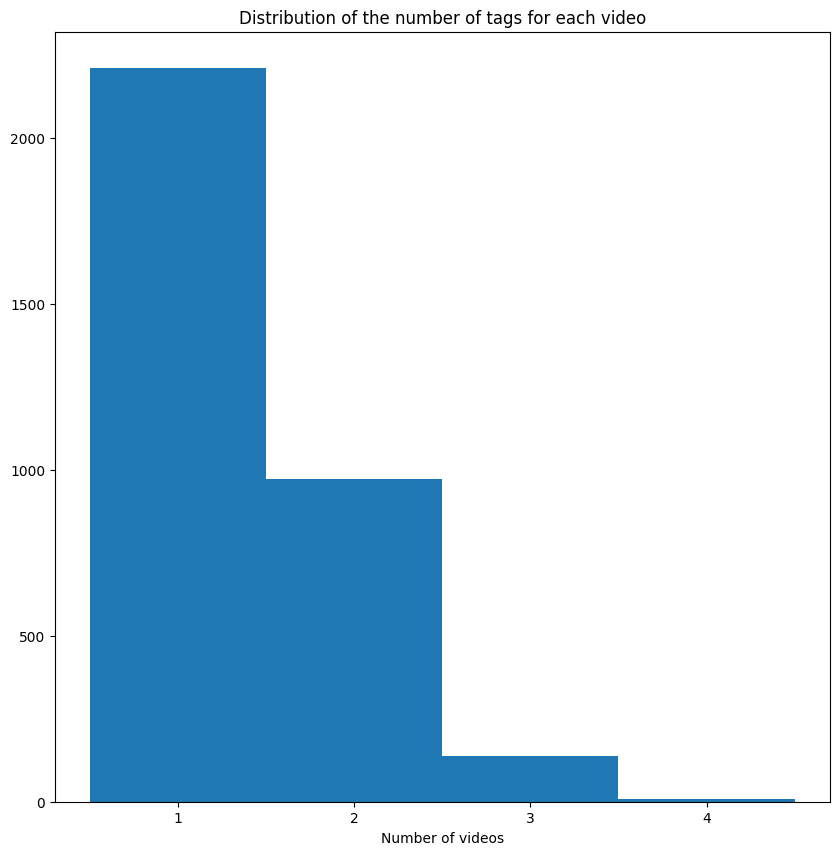

In [128]:
plt.figure(figsize=(10, 10))
tags = items['feat'].apply(len)
plt.hist(tags, bins=np.arange(tags.min(), tags.max() + 2) - 0.5)
plt.xticks(np.arange(tags.min(), tags.max() + 1))
plt.xlabel('Number of tags')
plt.xlabel('Number of videos')
plt.title('Distribution of the number of tags for each video')
plt.show()

In [129]:
from itertools import chain
from collections import Counter

# By curiosity, I want to know what is the most used tag

all_tags = list(chain.from_iterable(items['feat']))
tag_counts = Counter(all_tags)

In [130]:
most_common_tag, count = tag_counts.most_common(1)[0]
most_common_tag, count

(28, 849)

In [131]:
print(f"Most used tag: {most_common_tag} (used {count} times)")

Most used tag: 28 (used 849 times)


In [132]:
item_daily.head()

,video_id,date,author_id,video_type,upload_dt,upload_type,visible_status,video_duration,video_width,video_height,...,download_cnt,download_user_num,report_cnt,report_user_num,reduce_similar_cnt,reduce_similar_user_num,collect_cnt,collect_user_num,cancel_collect_cnt,cancel_collect_user_num
0,0,20200705,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,8,8,0,0,3,3,NaN,NaN,NaN,NaN
1,0,20200706,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,2,2,0,0,5,5,NaN,NaN,NaN,NaN
2,0,20200707,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,2,2,0,0,0,0,NaN,NaN,NaN,NaN
3,0,20200708,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,3,3,0,0,3,3,NaN,NaN,NaN,NaN
4,0,20200709,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,...,2,2,2,1,1,1,NaN,NaN,NaN,NaN


In [133]:
item_daily.shape

(343341, 58)

In [134]:
item_daily = item_daily[item_daily['video_id'].isin(interactions['video_id'])]

In [135]:
item_daily.shape

(137936, 58)

### Remark!

The following graph shows something very interesting: the lifetime of a video. As we can see with video `103`, it has been spread widely on the platform when the author published the video. Then, it starts losing popularity over the time and sometimes, the video seems to be recommended by the algorith/regain popularity. 

This is the kind of situation I am looking for when thinking of implementing a recommender algorithm: I want to recommend a video again later because it might suit with the context of my users, of popular trends, ...

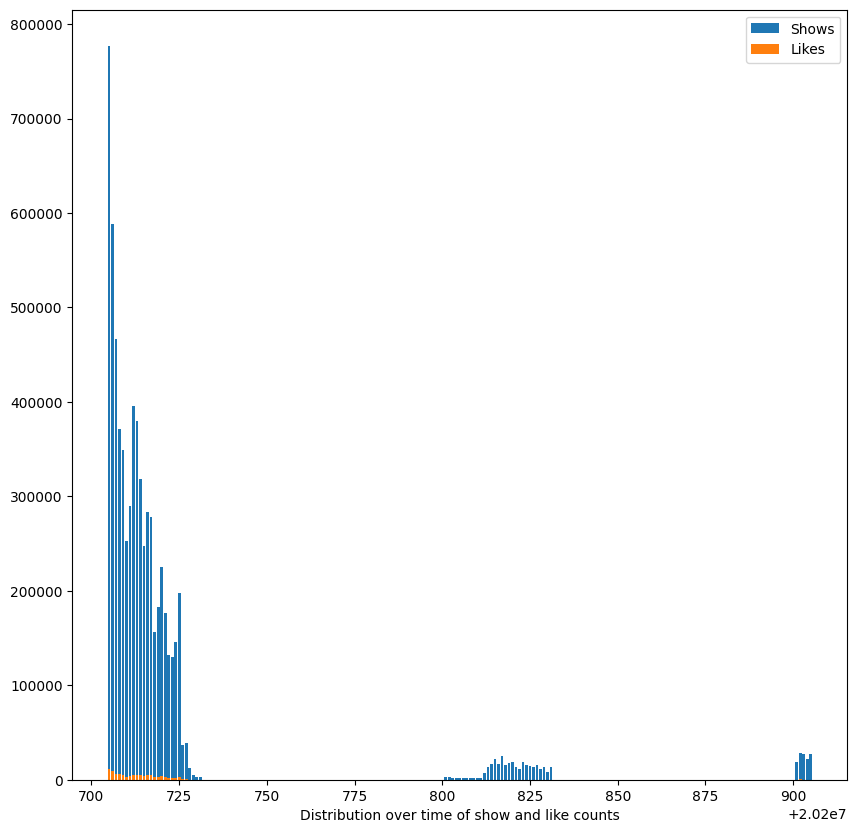

In [ ]:
plt.figure(figsize=(10, 10))
item_data = item_daily[item_daily['video_id'] == 103].sort_values('date')
plt.bar(height=item_data['show_cnt'], x=item_data['date'], label='Shows')
plt.bar(height=item_data['like_cnt'], x=item_data['date'], label='Likes')
plt.legend()
plt.xlabel('Distribution over time of show and like counts')
plt.show()

In [137]:
# Group by video_id the interactions to get information about the video

item_agg = item_daily.sort_values('date').groupby('video_id').agg({
    'date': 'last',
    'video_type': 'last',
    'visible_status': 'last',
    'show_cnt': 'sum',
    'upload_type': 'last',
    'music_id': 'nunique',
    'video_tag_id': lambda x: set(x)
})

item_agg.head()

,date,video_type,visible_status,show_cnt,upload_type,music_id,video_tag_id
video_id,,,,,,,
103,20200905,NORMAL,public,6886568,Kmovie,1,"{2491, 12}"
109,20200905,NORMAL,public,1338871,ShortCamera,1,"{18, 2701}"
120,20200905,NORMAL,public,2649109,ShortImport,1,"{0, 9}"
122,20200905,NORMAL,public,738469,Kmovie,1,"{9, 19}"
128,20200905,NORMAL,public,27471863,ShortImport,1,"{0, 12}"


## EDA Summary

I have now intuition about the data I will manipulate to build the embeddings and the future models to recommend videos. Moreover, I can visualize distributions of different aspect of users or videos that help me to choose which features to use and how to use them. Next step is now to construct embeddings to feed the models to recommend videos! (See `content_embedding` notebook!)